# Part 2 - Modelagem do Lubrication Model - `starved lubrication`

Para cada asset temos um `fit.npz`  e um `predict.npz`.

Devemos medir o quanto o `predict` se afastou do baseline saudavel do proprio asset(`fit`).

Converter esse afastamento em score entre 0 e 1.

Aplicar a regra fixa do challenge: se o percentil 75 dos scores passar de 0.75, o asset e classificado como `starved lubrication`.

In [1]:
# imports

from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal, stats
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

SEMENTE = 42
EPS = 1e-12

# Use 20 para o notebook rodar rapido. Use None para avaliar todos os sinais.
MAX_SINAIS_FIT = 20
MAX_SINAIS_PREDICT = 20


def encontrar_raiz_do_projeto():
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / 'pyproject.toml').exists() and (candidato / 'src').exists():
            return candidato
    return atual


RAIZ = encontrar_raiz_do_projeto()
CANDIDATOS_PART2 = [RAIZ / 'source' / 'part2', RAIZ / 'data' / 'part2']
PASTA_PART2 = next((p for p in CANDIDATOS_PART2 if (p / 'labels.csv').exists()), None)

if PASTA_PART2 is None:
    raise FileNotFoundError(f'Dados da Part 2 nao encontrados em: {CANDIDATOS_PART2}')

PASTA_ASSETS = PASTA_PART2 / 'assets'
PASTA_TESTE = PASTA_PART2 / 'test_data'
PASTA_MODELOS = RAIZ / 'models' / 'part2'
CAMINHO_CONFIG = PASTA_MODELOS / 'lubrication_model_config.pkl'

print('Dados Part 2:', PASTA_PART2)
print('Config sera salva em:', CAMINHO_CONFIG)


Dados Part 2: C:\Users\vinicius\Documents\MEUGITHUB\Vibration_challenge\source\part2
Config sera salva em: C:\Users\vinicius\Documents\MEUGITHUB\Vibration_challenge\models\part2\lubrication_model_config.pkl


In [2]:
# assets que temos e seus labels

labels = pd.read_csv(PASTA_PART2 / 'labels.csv')
labels['asset_id'] = labels['asset_id'].astype(str)
labels['is_starved'] = labels['label'].str.lower().str.contains('starved')

ids_assets = {p.name for p in PASTA_ASSETS.iterdir() if p.is_dir()}
labels_com_pasta = labels[labels['asset_id'].isin(ids_assets)].copy()

print('Assets com label:', len(labels))
print('Assets com label e pasta:', len(labels_com_pasta))
print('Pastas em assets sem label:', len(ids_assets - set(labels['asset_id'])))
display(labels['label'].value_counts().rename('quantidade').to_frame())

Assets com label: 144
Assets com label e pasta: 144
Pastas em assets sem label: 2


,quantidade
label,
healthy,96
starved lubrication,48


In [3]:
# carregamento dos arquivos .npz
def carregar_npz(asset_id, split, base_dir=PASTA_ASSETS):
    caminho = base_dir / asset_id / f'{split}.npz'
    npz = np.load(caminho, allow_pickle=False)
    return {
        'data': npz['data'].astype(np.float64),
        'dt': npz['dt'].astype(np.float64),
        'sample_ids': npz['sample_ids'].astype(str),
    }

# Função para limitar a quantidade de sinais
def escolher_indices(n, max_sinais):
    if max_sinais is None or n <= max_sinais:
        return np.arange(n)
    return np.linspace(0, n - 1, max_sinais, dtype=int) 


exemplo_asset = labels_com_pasta['asset_id'].iloc[0]
exemplo_fit = carregar_npz(exemplo_asset, 'fit')
exemplo_predict = carregar_npz(exemplo_asset, 'predict')

print('Exemplo asset:', exemplo_asset)
print('fit:', exemplo_fit['data'].shape)
print('predict:', exemplo_predict['data'].shape)
print('fs mediana fit:', round(float(np.median(1 / exemplo_fit['dt'])), 2))


Exemplo asset: 66c44a1e-4b0b-46ad-b739-4a961362b68b
fit: (60, 32000)
predict: (30, 32000)
fs mediana fit: 16000.0


Features no tempo:

- `rms`: energia media do sinal.
- `crest_factor`: relacao entre pico e RMS.
- `kurtosis_tempo`: ajuda a detectar impulsividade.

Features espectrais:

- `energia_acima_1k_frac`: fracao de energia acima de 1000 Hz.
- `energia_acima_3k_frac`: fracao de energia acima de 3000 Hz.
- `energia_3_6k_frac`: fracao na banda 3000-6000 Hz.
- `centroide_espectral`: deslocamento da energia para frequencias mais altas.
- `entropia_espectral`: energia mais espalhada no espectro.
- `flatness_espectral`: espectro mais plano, associado a comportamento broadband.
- `log_psd_mediana_acima_1k`: piso espectral acima de 1000 Hz.
- `log_psd_q90_acima_1k`: energia alta nas maiores faixas do espectro.

In [4]:
def calcular_psd(sinal, dt, nperseg=4096):
    fs = 1.0 / dt
    sinal = np.asarray(sinal, dtype=np.float64)
    sinal = signal.detrend(sinal - np.mean(sinal), type='linear')
    nperseg = min(nperseg, len(sinal))
    freq, psd = signal.welch(
        sinal,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2,
        scaling='density',
    )
    return freq, psd


def area_banda(freq, psd, inicio, fim):
    mascara = (freq >= inicio) & (freq < fim)
    if mascara.sum() < 2:
        return 0.0
    return float(np.trapz(psd[mascara], freq[mascara]))


def entropia_espectral(psd):
    energia = np.maximum(psd, EPS)
    prob = energia / (np.sum(energia) + EPS)
    if len(prob) <= 1:
        return 0.0
    return float(-np.sum(prob * np.log2(prob + EPS)) / np.log2(len(prob)))


def flatness_espectral(psd):
    energia = np.maximum(psd, EPS)
    return float(np.exp(np.mean(np.log(energia))) / (np.mean(energia) + EPS))


def extrair_features_sinal(sinal, dt):
    sinal = np.asarray(sinal, dtype=np.float64)
    sinal_sem_media = sinal - np.mean(sinal)

    rms = float(np.sqrt(np.mean(sinal_sem_media ** 2)))
    max_abs = float(np.max(np.abs(sinal_sem_media)))

    freq, psd = calcular_psd(sinal_sem_media, dt)
    energia_total = area_banda(freq, psd, 0, freq.max()) + EPS
    energia_acima_1k = area_banda(freq, psd, 1000, freq.max())
    energia_acima_3k = area_banda(freq, psd, 3000, freq.max())
    energia_3_6k = area_banda(freq, psd, 3000, 6000)

    mascara_acima_1k = freq >= 1000
    log_psd_acima_1k = 10 * np.log10(psd[mascara_acima_1k] + EPS)

    return {
        'rms': rms,
        'crest_factor': max_abs / (rms + EPS),
        'kurtosis_tempo': float(stats.kurtosis(sinal_sem_media, fisher=True, bias=False)),
        'energia_acima_1k_frac': energia_acima_1k / energia_total,
        'energia_acima_3k_frac': energia_acima_3k / energia_total,
        'energia_3_6k_frac': energia_3_6k / energia_total,
        'centroide_espectral': float(np.sum(freq * psd) / (np.sum(psd) + EPS)),
        'entropia_espectral': entropia_espectral(psd),
        'flatness_espectral': flatness_espectral(psd),
        'log_psd_mediana_acima_1k': float(np.median(log_psd_acima_1k)),
        'log_psd_q90_acima_1k': float(np.percentile(log_psd_acima_1k, 90)),
    }


FEATURES_USADAS = [
    'rms',
    'energia_acima_1k_frac',
    'energia_acima_3k_frac',
    'energia_3_6k_frac',
    'centroide_espectral',
    'entropia_espectral',
    'log_psd_mediana_acima_1k',
    'log_psd_q90_acima_1k',
]

PESOS_FEATURES = {
    'rms': 0.8,
    'energia_acima_1k_frac': 1.2,
    'energia_acima_3k_frac': 1.2,
    'energia_3_6k_frac': 1.0,
    'centroide_espectral': 1.0,
    'entropia_espectral': 0.7,
    'log_psd_mediana_acima_1k': 1.5,
    'log_psd_q90_acima_1k': 1.5,
}


Para cada asset, calculamos baseline no `fit`:

```text
mediana_fit(feature)
IQR_fit(feature)
```

Depois, para cada sinal de `predict`, calculamos:

```text
z = (feature_predict - mediana_fit) / IQR_fit
```

Depois combinamos os `z` com pesos e aplicamos uma sigmoid para gerar score entre 0 e 1.

In [5]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class ModeloLubrificacao:
    def __init__(
        self,
        features_usadas=FEATURES_USADAS,
        pesos_features=PESOS_FEATURES,
        centro_score=5.0,
        escala_score=4.0,
        max_z=12.0,
    ):
        self.features_usadas = list(features_usadas)
        self.pesos_features = dict(pesos_features)
        self.centro_score = float(centro_score)
        self.escala_score = float(escala_score)
        self.max_z = float(max_z)
        self.baseline_mediana_ = None
        self.baseline_escala_ = None
        self.features_fit_ = None

    def fit(self, sinais_fit, dts_fit, max_sinais=MAX_SINAIS_FIT):
        linhas = []
        for i in escolher_indices(len(sinais_fit), max_sinais):
            linhas.append(extrair_features_sinal(sinais_fit[i], dts_fit[i]))

        features_fit = pd.DataFrame(linhas)
        baseline = features_fit[self.features_usadas]
        escala = baseline.quantile(0.75) - baseline.quantile(0.25)
        escala = escala.replace(0, np.nan).fillna(baseline.std().replace(0, np.nan)).fillna(1.0)

        self.features_fit_ = features_fit
        self.baseline_mediana_ = baseline.median()
        self.baseline_escala_ = escala + EPS
        return self

    def score_bruto(self, features_sinal):
        valores = pd.Series(features_sinal)[self.features_usadas]
        z = (valores - self.baseline_mediana_) / self.baseline_escala_
        z = z.clip(lower=0, upper=self.max_z)

        peso_total = sum(self.pesos_features[f] for f in self.features_usadas)
        bruto = sum(self.pesos_features[f] * z[f] for f in self.features_usadas) / peso_total
        return float(bruto), z

    def predict_sample(self, sinal, dt):
        features = extrair_features_sinal(sinal, dt)
        bruto, z = self.score_bruto(features)
        score = sigmoid((bruto - self.centro_score) / self.escala_score)
        return float(score), float(bruto), features, z

    def predict(self, sinais_predict, dts_predict, max_sinais=MAX_SINAIS_PREDICT):
        scores = []
        brutos = []
        linhas = []

        for i in escolher_indices(len(sinais_predict), max_sinais):
            score, bruto, features, z = self.predict_sample(sinais_predict[i], dts_predict[i])
            scores.append(score)
            brutos.append(bruto)
            linha = {'indice_sinal': int(i), 'score': score, 'score_bruto': bruto}
            linha.update({f'z_{col}': float(z[col]) for col in self.features_usadas})
            linhas.append(linha)

        scores = np.asarray(scores, dtype=float)
        decisao = float(np.percentile(scores, 75)) > 0.75
        diagnostico = pd.DataFrame(linhas)
        return bool(decisao), scores, brutos, diagnostico


In [6]:
# Testando com um caso positivo e um negativo
asset_healthy = labels_com_pasta.loc[~labels_com_pasta['is_starved'], 'asset_id'].iloc[0]
asset_starved_preferido = '3c63de33-c64e-4271-bae6-117016a42505'
if asset_starved_preferido in set(labels_com_pasta['asset_id']):
    asset_starved = asset_starved_preferido
else:
    asset_starved = labels_com_pasta.loc[labels_com_pasta['is_starved'], 'asset_id'].iloc[0]


def rodar_asset(asset_id, base_dir=PASTA_ASSETS):
    fit = carregar_npz(asset_id, 'fit', base_dir=base_dir)
    pred = carregar_npz(asset_id, 'predict', base_dir=base_dir)
    modelo = ModeloLubrificacao().fit(fit['data'], fit['dt'])
    decisao, scores, brutos, diagnostico = modelo.predict(pred['data'], pred['dt'])
    return modelo, decisao, scores, brutos, diagnostico


for asset_id in [asset_healthy, asset_starved]:
    modelo_tmp, decisao, scores, brutos, diagnostico = rodar_asset(asset_id)
    label_real = labels_com_pasta.loc[labels_com_pasta['asset_id'] == asset_id, 'label'].iloc[0]
    print('\nAsset:', asset_id)
    print('Label real:', label_real)
    print('Predicao:', 'starved lubrication' if decisao else 'healthy')
    print('Score mediano:', round(float(np.median(scores)), 3))
    print('Score p75:', round(float(np.percentile(scores, 75)), 3))
    display(diagnostico.head())



Asset: 66c44a1e-4b0b-46ad-b739-4a961362b68b
Label real: healthy
Predicao: healthy
Score mediano: 0.244
Score p75: 0.254


,indice_sinal,score,score_bruto,z_rms,z_energia_acima_1k_frac,z_energia_acima_3k_frac,z_energia_3_6k_frac,z_centroide_espectral,z_entropia_espectral,z_log_psd_mediana_acima_1k,z_log_psd_q90_acima_1k
0,0,0.224105,0.032383,0.188828,0.000000,0.000000,0.000000,0.000000,0.195920,0.000000,0.000000
1,1,0.237342,0.330774,1.998332,0.013196,0.075224,0.000000,0.021798,0.000000,0.000000,0.811549
2,3,0.255466,0.721316,0.394760,0.934892,0.709596,0.744533,0.819182,0.550056,0.483992,0.970520
3,4,0.225372,0.061475,0.108234,0.099280,0.065181,0.004987,0.000000,0.000000,0.000000,0.172134
4,6,0.279271,1.207675,2.236543,0.718915,0.527889,0.385009,0.752595,1.010128,2.377944,1.367531



Asset: 3c63de33-c64e-4271-bae6-117016a42505
Label real: starved lubrication
Predicao: starved lubrication
Score mediano: 0.776
Score p75: 0.776


,indice_sinal,score,score_bruto,z_rms,z_energia_acima_1k_frac,z_energia_acima_3k_frac,z_energia_3_6k_frac,z_centroide_espectral,z_entropia_espectral,z_log_psd_mediana_acima_1k,z_log_psd_q90_acima_1k
0,0,0.776326,9.977528,12.0,12.0,12.0,12.0,12.0,12.0,0.0,12.0
1,1,0.776326,9.977528,12.0,12.0,12.0,12.0,12.0,12.0,0.0,12.0
2,3,0.776326,9.977528,12.0,12.0,12.0,12.0,12.0,12.0,0.0,12.0
3,4,0.776326,9.977528,12.0,12.0,12.0,12.0,12.0,12.0,0.0,12.0
4,6,0.776326,9.977528,12.0,12.0,12.0,12.0,12.0,12.0,0.0,12.0


# Avaliação dos outros ativos

In [7]:
linhas_resultado = []
diagnosticos_por_asset = {}

for row in labels_com_pasta.itertuples(index=False):
    modelo_asset, predicao_starved, scores, brutos, diagnostico = rodar_asset(row.asset_id)
    diagnosticos_por_asset[row.asset_id] = diagnostico
    linhas_resultado.append({
        'asset_id': row.asset_id,
        'label': row.label,
        'is_starved': bool(row.is_starved),
        'pred_starved': bool(predicao_starved),
        'score_p50': float(np.percentile(scores, 50)),
        'score_p75': float(np.percentile(scores, 75)),
        'score_p90': float(np.percentile(scores, 90)),
        'score_max': float(np.max(scores)),
        'score_bruto_p75': float(np.percentile(brutos, 75)),
    })

resultados = pd.DataFrame(linhas_resultado)

y_real = resultados['is_starved']
y_pred = resultados['pred_starved']

metricas = {
    'accuracy': accuracy_score(y_real, y_pred),
    'precision': precision_score(y_real, y_pred, zero_division=0),
    'recall': recall_score(y_real, y_pred, zero_division=0),
    'f1': f1_score(y_real, y_pred, zero_division=0),
}

print(metricas)
print(classification_report(y_real, y_pred, target_names=['healthy', 'starved'], digits=3, zero_division=0))

display(resultados.head())

{'accuracy': 0.9027777777777778, 'precision': 0.9047619047619048, 'recall': 0.7916666666666666, 'f1': 0.8444444444444444}
              precision    recall  f1-score   support

     healthy      0.902     0.958     0.929        96
     starved      0.905     0.792     0.844        48

    accuracy                          0.903       144
   macro avg      0.903     0.875     0.887       144
weighted avg      0.903     0.903     0.901       144



,asset_id,label,is_starved,pred_starved,score_p50,score_p75,score_p90,score_max,score_bruto_p75
0,66c44a1e-4b0b-46ad-b739-4a961362b68b,healthy,False,False,0.244100,0.254179,0.261931,0.279271,0.694193
1,0f193b25-e6b8-4f69-875f-2cfa553fe0d2,healthy,False,False,0.321559,0.327827,0.364934,0.407482,2.127838
2,3eff280f-06fc-4b1d-adff-4022164cecff,healthy,False,False,0.239836,0.251569,0.281529,0.300455,0.638895
3,11d95534-6903-497b-af14-ec36443db1a5,healthy,False,False,0.313754,0.321182,0.340226,0.359861,2.006604
4,c66f58d9-5fb9-4615-89de-a0249655b134,healthy,False,False,0.295082,0.299539,0.306771,0.310998,1.602027


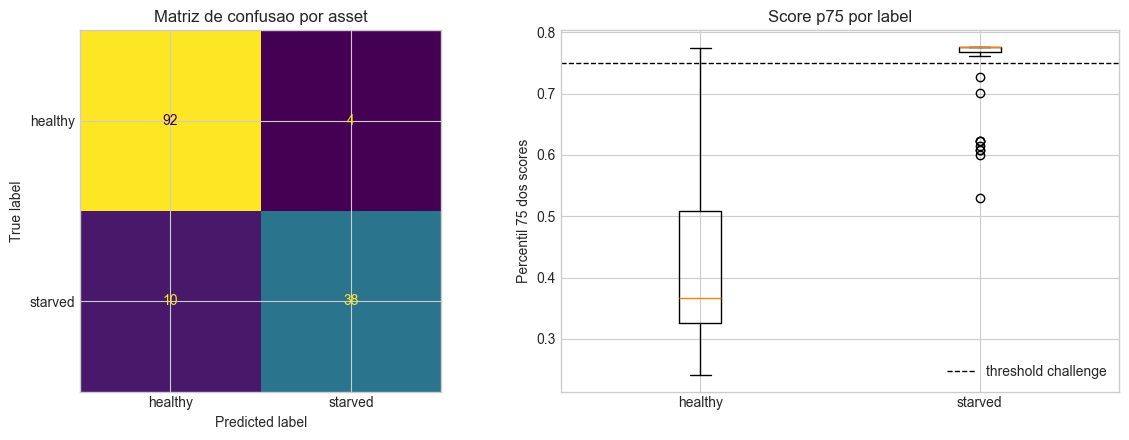

In [8]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_real,
    y_pred,
    display_labels=['healthy', 'starved'],
    ax=eixos[0],
    colorbar=False,
)
eixos[0].set_title('Matriz de confusao por asset')

dados_plot = [
    resultados.loc[resultados['label'] == label, 'score_p75'].dropna()
    for label in ['healthy', 'starved lubrication']
]
eixos[1].boxplot(dados_plot, labels=['healthy', 'starved'])
eixos[1].axhline(0.75, color='black', ls='--', lw=1, label='threshold challenge')
eixos[1].set_title('Score p75 por label')
eixos[1].set_ylabel('Percentil 75 dos scores')
eixos[1].legend(loc='best')

plt.tight_layout();


# Análises de casos de falsos positivos

In [9]:
falsos_positivos = resultados[(~resultados['is_starved']) & (resultados['pred_starved'])].sort_values('score_p75', ascending=False)
falsos_negativos = resultados[(resultados['is_starved']) & (~resultados['pred_starved'])].sort_values('score_p75')

print('Falsos positivos:', len(falsos_positivos))
display(falsos_positivos[['asset_id', 'label', 'score_p75', 'score_p90', 'score_bruto_p75']].head(10))

print('Falsos negativos:', len(falsos_negativos))
display(falsos_negativos[['asset_id', 'label', 'score_p75', 'score_p90', 'score_bruto_p75']].head(10))


Falsos positivos: 4


,asset_id,label,score_p75,score_p90,score_bruto_p75
80,fea05515-a0c2-416d-9336-c8bcc7de5404,healthy,0.773602,0.773995,9.915042
82,74091ba5-b7cc-457b-9444-551dd97e976f,healthy,0.769550,0.770414,9.823091
81,a444f035-5e3d-4b80-b80e-864b6427924c,healthy,0.760424,0.762367,9.620029
107,2af1e1d4-8628-4d62-834a-33b5c5cfc59e,healthy,0.756768,0.759910,9.540178


Falsos negativos: 10


,asset_id,label,score_p75,score_p90,score_bruto_p75
43,eff2b716-d8cc-4705-a16b-c665ce3c5e78,starved lubrication,0.529182,0.534081,5.467447
41,a3111451-9772-4fcf-9911-eee492620fa6,starved lubrication,0.599590,0.602327,6.615039
40,14b510db-2d4e-461e-86ad-186f8734681f,starved lubrication,0.608311,0.621384,6.760875
17,e2a7c182-c81a-472f-b0ac-de67b74a3928,starved lubrication,0.608615,0.613715,6.765982
16,98e8ca60-4497-40e3-897f-f4cc61ca87dc,starved lubrication,0.614538,0.618698,6.865723
18,b6d3d3e4-e5e1-45c1-87a1-6ee53b509022,starved lubrication,0.623119,0.623119,7.011236
19,bce89700-aacf-4c1d-91a6-3ab29f858bea,starved lubrication,0.623119,0.623119,7.011236
42,c6d8ecc3-2281-4ebb-8b7f-b8b1933eb4f6,starved lubrication,0.623119,0.623119,7.011236
89,46dcdd8c-9242-49ec-a7ed-6d00c5e22ab0,starved lubrication,0.700595,0.712074,8.400524
88,28fb42ee-65e2-4b3d-844e-3b6ad97991b4,starved lubrication,0.726718,0.755040,8.912161


# Previsão dos casos sem label

In [10]:
linhas_teste = []
for asset_dir in sorted([p for p in PASTA_TESTE.iterdir() if p.is_dir()]):
    asset_id = asset_dir.name
    modelo_asset, predicao_starved, scores, brutos, diagnostico = rodar_asset(asset_id, base_dir=PASTA_TESTE)
    linhas_teste.append({
        'asset_id': asset_id,
        'predicao': 'starved lubrication' if predicao_starved else 'healthy',
        'score_p50': float(np.percentile(scores, 50)),
        'score_p75': float(np.percentile(scores, 75)),
        'score_p90': float(np.percentile(scores, 90)),
        'score_max': float(np.max(scores)),
    })

predicoes_teste = pd.DataFrame(linhas_teste).sort_values('score_p75', ascending=False)
display(predicoes_teste)


,asset_id,predicao,score_p50,score_p75,score_p90,score_max
18,ed9f0130-ebfe-4b76-ae6c-144faf1e5fcc,starved lubrication,0.776326,0.776326,0.776326,0.776326
8,698c671e-75ab-4dee-8efb-75b0d0cfba33,starved lubrication,0.776326,0.776326,0.776326,0.776326
9,7bc09894-933a-4bfe-90e5-19da8bac8a53,starved lubrication,0.776326,0.776326,0.776326,0.776326
17,e66af937-79f9-4c12-bc99-f08b998a9bcd,starved lubrication,0.770937,0.774580,0.776326,0.776326
13,b425a6af-95f3-47c4-86ef-11ddcd869e1e,healthy,0.730081,0.738252,0.745538,0.749330
4,4edf71bf-0b25-4870-9770-63a10ba42ca6,healthy,0.715688,0.732374,0.741572,0.756225
10,924fbf22-86e6-402e-a066-8126adc28908,healthy,0.592863,0.620970,0.639297,0.666758
7,649b99cf-1dcb-4ffc-91ff-b0aae82d4a49,healthy,0.606145,0.618346,0.623119,0.623119
1,16a8370c-1a96-47fa-a8db-1b71347a2dc5,healthy,0.583492,0.601700,0.621148,0.658171
15,d7e9e629-9095-4660-adbc-e827d65d06b8,healthy,0.441974,0.579169,0.622163,0.645454


# Save do Modelo

In [11]:
config_modelo = {
    'features_usadas': FEATURES_USADAS,
    'pesos_features': PESOS_FEATURES,
    'centro_score': 5.0,
    'escala_score': 4.0,
    'max_z': 12.0,
    'max_sinais_fit_notebook': MAX_SINAIS_FIT,
    'max_sinais_predict_notebook': MAX_SINAIS_PREDICT,
    'metricas_assets_labeled': metricas,
    'observacao': 'Modelo baseado em baseline robusto por asset. A regra final usa percentil 75 > 0.75, como no challenge.',
}

PASTA_MODELOS.mkdir(parents=True, exist_ok=True)
joblib.dump(config_modelo, CAMINHO_CONFIG)
print('Config salva em:', CAMINHO_CONFIG)


Config salva em: C:\Users\vinicius\Documents\MEUGITHUB\Vibration_challenge\models\part2\lubrication_model_config.pkl
